In [1]:
#SCALAR GAUSS BONNET MODIFIED EXAMPLE

# Isotropic Schwarzschild BH example
# see further details in https://github.com/GRChombo/engrenage/wiki/Running-the-black-hole-example

# restart the kernel to clear past work
# (can also do this manually from the Kernel options above)
from IPython.core.display import HTML
HTML("<script>Jupyter.notebook.kernel.restart()</script>")

# load the required python modules
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import time
import sys
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

# homemade source code from source folder
sys.path.append('/Users/serdaryildiz/Desktop/GRSerdar/engrenage/source')

from initialdata.bhinitialconditions import *
from backgrounds.sphericalbackground import *
from bssn.constraintsdiagnostic import *
from bssn.ahfinder import *
from core.rhsevolution import *
from core.grid import Grid
from core.spacing import *
from core.display import *
from core.statevector import *
from matter.scalarmatter import *

In [2]:
# Set up the chosen matter class
scalar_mu = 1.0
my_matter = ScalarMatter(scalar_mu)
my_state_vector = StateVector(my_matter)

# Input parameters for grid and evolution here
r_max = 96.0 # outer edge of the grid (including ghosts)
#min_dr = 1 / 16 # roughly 32 points across the BH

min_dr = 1/16
#min_dr = 1 / 64
max_dr = 2

# SinhSpacing
# params = SinhSpacing.get_parameters(r_max, min_dr, max_dr)
# spacing = SinhSpacing(**params)

# CubicSpacing
params = CubicSpacing.get_parameters(r_max, min_dr, max_dr)
spacing = CubicSpacing(**params)

grid = Grid(spacing, my_state_vector)
r = grid.r
num_points = r.size
background = FlatSphericalBackground(r)

# Check grid params
print(params)

#########################################################################################

initial_state = get_initial_state(grid, background)

#unpackage the vector for readability
(initial_phi, initial_hrr, initial_htt, initial_hpp, 
 initial_K, initial_arr, initial_att, initial_app, 
 initial_lambdar, initial_shiftr, initial_br, initial_lapse, 
 initial_u, initial_v) = np.array_split(initial_state, grid.NUM_VARS)

#########################################################################################

# Check that for a higher resolution the Ham constraint converges (the Mom constraint is trivially zero)

# Input parameters for HR grid
min_dr_HR = 1 / 32 # roughly 64 points across the BH
max_dr_HR = 1

# CubicSpacing
params_HR = CubicSpacing.get_parameters(r_max, min_dr_HR, max_dr_HR)
spacing_HR = CubicSpacing(**params_HR)

grid_HR = Grid(spacing_HR, my_state_vector)
r_HR = grid_HR.r
num_points_HR = r_HR.size
background_HR = FlatSphericalBackground(r_HR)

# Check grid params
print(params_HR)

# Get initial state
initial_state_HR = get_initial_state(grid_HR, background_HR)

{'r_max': 96.0, 'extent': <SpacingExtent.HALF: 0>, 'a': 1.5213625583444466, 'num_points': 140}
{'r_max': 96.0, 'extent': <SpacingExtent.HALF: 0>, 'a': 1.5213625583444466, 'num_points': 275}


# Start running the simulation

In [4]:
# for control of time integrator and spatial grid
#T = 10 # Maximum evolution time
T = 20
#num_points_t = 128 # time resolution (only for outputs, not for integration, which is decided by python)
num_points_t = 250

# Work out dt and time spacing of outputs
dt = T/num_points_t
t = np.linspace(0, T-dt, num_points_t)

# Solve for the solution using RK45 integration of the ODE
# to make like (older) python odeint method use method='LSODA' instead
# use tqdm package to track progress
with tqdm(total=1000, unit="‰") as progress_bar:
    dense_solution = solve_ivp(get_rhs, [0,T], initial_state, 
                               args=(grid, background, my_matter, progress_bar, [0, T/1000]),
                        #atol=1e-5, rtol=1e-5,
                        max_step = 0.4 * min_dr, #for stability and for KO coeff of 1
                        method='RK45', dense_output=True)

# Interpolate the solution at the time points requestedf
solution = dense_solution.sol(t).T

  0%|          | 0/1000 [00:00<?, ?‰/s]

# Kretschmann scalar VS LGB term

The coordinate transformation to go from Schwarzschild ($r$) to isotropic ($R$) coordinates

$r = R \left( 1+\frac{(M)^2}{4R}\right)$

In Schwarzschil coordinates the K scalar is given by

$K = \frac{48}{r^6}$

Hence what we need

$K = \frac{48}{\left(R \left( 1+\frac{(M)^2}{4R}\right)\right)^6}$

The K scalar is equal to the GB term at first order (if we neglect backreaction)

 

In [5]:
# To obtain the scalar K in iso SZ coordinates

def iso_to_sz(R):
    return R*(1+ 1/(2*R))**2
    
def Kretschmann(r):
    return 48/(r**6)

# Comparing the Kretschman scalar with gaussbonnet term 

## $ t= 0$

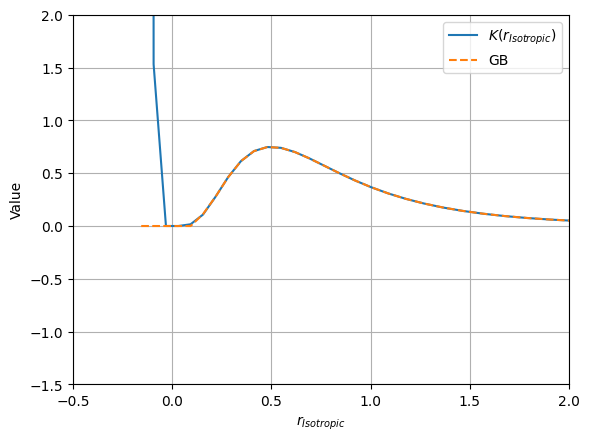

In [6]:
idx= 0 # time index
#idx = 0 #initial time 

Gausser = Gaur[idx]
'''line1 = LLine1[idx] 
line2 = LLine2[idx]
line3 = LLine3[idx]
line4 = LLine4[idx]'''

plt.plot(r, Kretschmann(iso_to_sz(r)), label='$K(r_{Isotropic})$', linestyle='-')

'''plt.plot(r, line1*r**6, label = 'line1')
plt.plot(r, line2*r**6, label = 'line2')
plt.plot(r, line3*r**6, label = 'line3')
plt.plot(r, line4*r**6, label = 'line4')
'''

plt.plot(r, Gausser, label = 'GB', linestyle="--")


plt.legend(loc='best')
plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend(loc='best')
'''plt.xlim(-0.1,2)
plt.ylim(-10,1200)'''


plt.xlim(-0.5,2)
plt.ylim(-1.5,2)

#plt.xlim(-5,80)
#plt.ylim(-5,90)
plt.grid()
#plt.savefig('KvsGB_t_0')

## $t\neq 0$

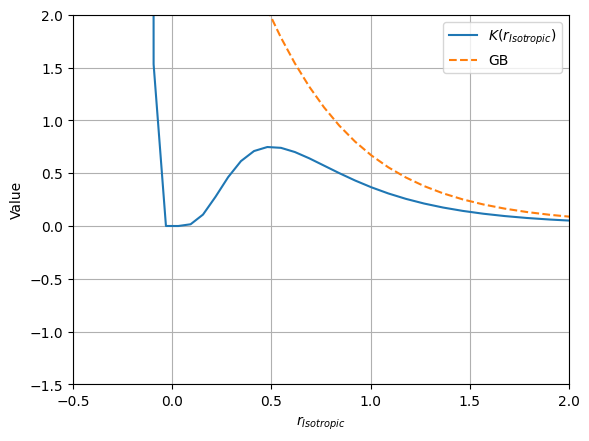

In [10]:
idx= -1 #time index
#idx = 0 #initial time 

Gausser = Gaur[idx]

#plt.plot(r, Kretschmann(iso_to_sz(r))*r**6, label='$K(r_{Isotropic})$', linestyle='-')
#plt.plot(r, Gausser*r**6, label = 'GB', linestyle="--")

plt.plot(r, Kretschmann(iso_to_sz(r)), label='$K(r_{Isotropic})$', linestyle='-')
plt.plot(r, Gausser, label = 'GB', linestyle="--")

plt.legend(loc='best')
plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend(loc='best')
'''plt.xlim(-0.1,2)
plt.ylim(-10,1200)'''

#plt.xlim(-5,80)
#plt.ylim(-5,90)

plt.xlim(-0.5,2)
plt.ylim(-1.5,2)
plt.grid()
# plt.savefig('KvsGB_t_not_0')

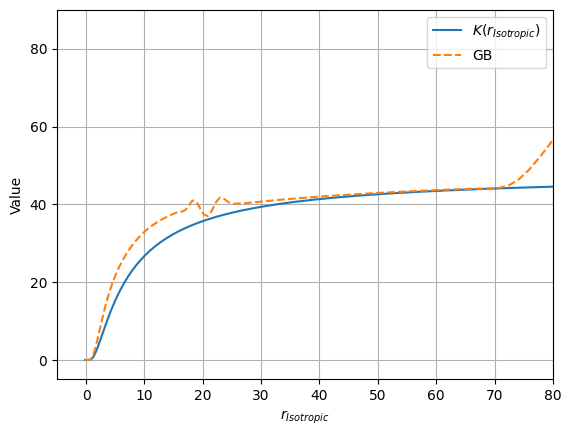

In [25]:
idx= 4700 #time index
#idx = 0 #initial time 

Gausser = Gaur[idx]

plt.plot(r, Kretschmann(iso_to_sz(r))*r**6, label='$K(r_{Isotropic})$', linestyle='-')
plt.plot(r, Gausser*r**6, label = 'GB', linestyle="--")


plt.legend(loc='best')
plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend(loc='best')
'''plt.xlim(-0.1,2)
plt.ylim(-10,1200)'''

plt.xlim(-5,80)
plt.ylim(-5,90)

plt.grid()
# plt.savefig('KvsGB_t_not_0')

# All lines in one plot

## $T=0$

In [9]:
idx= 0 #time index
#idx = 0 #initial time 

l1 = line1_[idx]
l2 = line2_[idx]
l3 = line3_[idx]
l4 = line4_[idx]


som = l1+l2+l3+l4

plt.plot(r, Kretschmann(iso_to_sz(r)), label='$K(r_{Isotropic})$', linestyle='--')

plt.plot(r, l1, label = 'line1', linestyle="-")
plt.plot(r, l2, label = 'line2', linestyle="-")
plt.plot(r, l3, label = 'line3', linestyle="-")
plt.plot(r, l4, label = 'line4', linestyle="--")

#plt.plot(r, som, label = 'som', linestyle="--")



plt.legend(loc='best')
plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend(loc='best')
'''plt.xlim(-0.1,2)
plt.ylim(-10,1200)'''

plt.xlim(-0.5,2)
plt.ylim(-1.5,2)

'''plt.xlim(-5,80)
plt.ylim(-5,90)'''
plt.grid()
# plt.savefig('KvsGB_t_not_0')

NameError: name 'line1_' is not defined

## $T\neq0$

In [ ]:
idx= -1 #time index
#idx = 0 #initial time 

l1 = line1_[idx]
l2 = line2_[idx]
l3 = line3_[idx]
l4 = line4_[idx]


som = l1+l2+l3+l4

plt.plot(r, Kretschmann(iso_to_sz(r)), label='$K(r_{Isotropic})$', linestyle='--')

plt.plot(r, l1, label = 'line1', linestyle="-")
plt.plot(r, l2, label = 'line2', linestyle="-")
plt.plot(r, l3, label = 'line3', linestyle="-")
plt.plot(r, l4, label = 'line4', linestyle="-")

plt.plot(r, som, label = 'som', linestyle="--")



plt.legend(loc='best')
plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend(loc='best')
'''plt.xlim(-0.1,2)
plt.ylim(-10,1200)'''

plt.xlim(-0.5,2)
plt.ylim(-1.5,2)

'''plt.xlim(-5,80)
plt.ylim(-5,90)'''
plt.grid()
# plt.savefig('KvsGB_t_not_0')

# Line 1

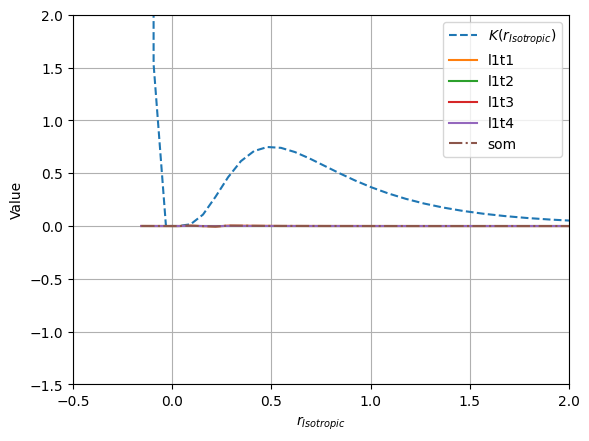

In [10]:
idx= -1 #time index
#idx = 0 #initial time 

l1t1 = line1_1[idx]
l1t2 = line1_2[idx]
l1t3 = line1_3[idx]
l1t4 = line1_4[idx]

som = l1t1+l1t2+l1t3+l1t4

plt.plot(r, Kretschmann(iso_to_sz(r)), label='$K(r_{Isotropic})$', linestyle='--')

plt.plot(r, l1t1, label = 'l1t1', linestyle="-")
plt.plot(r, l1t2, label = 'l1t2', linestyle="-")
plt.plot(r, l1t3, label = 'l1t3', linestyle="-")
plt.plot(r, l1t4, label = 'l1t4', linestyle="-")

plt.plot(r, som, label = 'som', linestyle="-.")



plt.legend(loc='best')
plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend(loc='best')
'''plt.xlim(-0.1,2)
plt.ylim(-10,1200)'''


plt.xlim(-0.5,2)
plt.ylim(-1.5,2)

'''plt.xlim(-5,80)
plt.ylim(-5,90)'''
plt.grid()
# plt.savefig('KvsGB_t_not_0')

# Line 2 

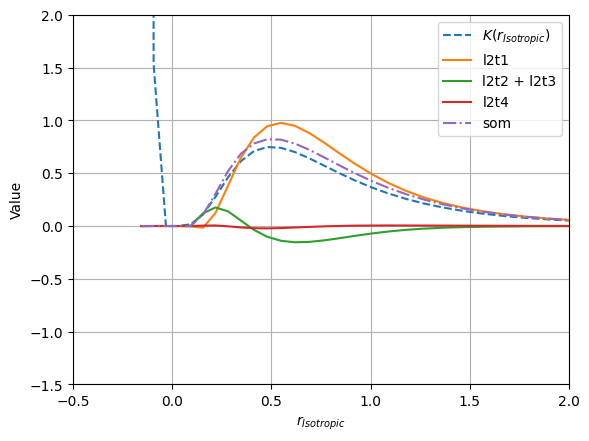

In [11]:
idx= -1 #time index
#idx = 0 #initial time 

l2t1 = line2_1[idx]
l2t2 = line2_2[idx]
l2t3 = line2_3[idx]
l2t4 = line2_4[idx]


som = l2t1+l2t2+l2t3+l2t4

plt.plot(r, Kretschmann(iso_to_sz(r)), label='$K(r_{Isotropic})$', linestyle='--')

plt.plot(r, l2t1, label = 'l2t1', linestyle="-")
plt.plot(r, l2t2+ l2t3, label = 'l2t2 + l2t3', linestyle="-")
#plt.plot(r, l2t3, label = 'l2t3', linestyle="--")
plt.plot(r, l2t4, label = 'l2t4', linestyle="-")

plt.plot(r, som, label = 'som', linestyle="-.")



plt.legend(loc='best')
plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend(loc='best')
'''plt.xlim(-0.1,2)
plt.ylim(-10,1200)'''


plt.xlim(-0.5,2)
plt.ylim(-1.5,2)

'''
plt.xlim(-5,80)
plt.ylim(-5,90)
'''
plt.grid()
# plt.savefig('KvsGB_t_not_0')

# Line 3

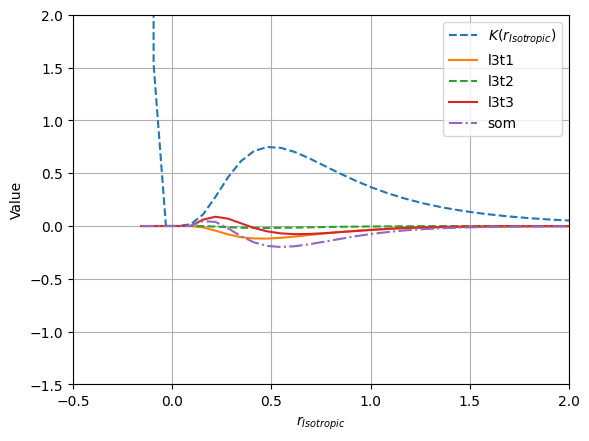

In [12]:
idx= -1 #time index
#idx = 0 #initial time 

l3t1 = line3_1[idx]
l3t2 = line3_2[idx]
l3t3 = line3_3[idx]

som = l3t1+l3t2 + l3t3

plt.plot(r, Kretschmann(iso_to_sz(r)), label='$K(r_{Isotropic})$', linestyle='--')

plt.plot(r, l3t1, label = 'l3t1', linestyle="-")
plt.plot(r, l3t2, label = 'l3t2', linestyle="--")
plt.plot(r, l3t3, label = 'l3t3', linestyle="-")

plt.plot(r, som, label = 'som', linestyle="-.")



plt.legend(loc='best')
plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend(loc='best')
'''plt.xlim(-0.1,2)
plt.ylim(-10,1200)'''


plt.xlim(-0.5,2)
plt.ylim(-1.5,2)

'''plt.xlim(-5,80)
plt.ylim(-5,90)'''
plt.grid()
# plt.savefig('KvsGB_t_not_0')

# Line 2 + Line 3 (since they are actually the same line)

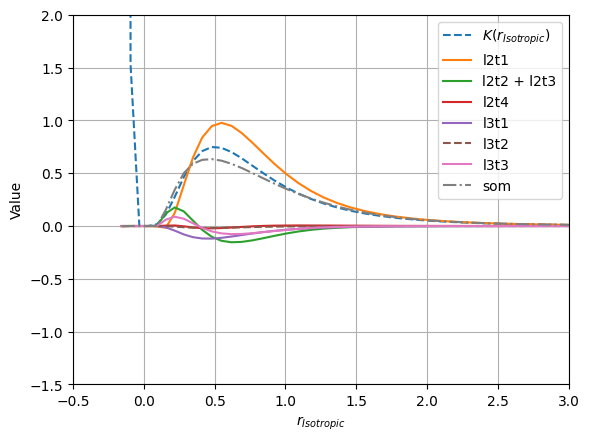

In [13]:
idx= -1 #time index
#idx = 0 #initial time 

l2t1 = line2_1[idx]
l2t2 = line2_2[idx]
l2t3 = line2_3[idx]
l2t4 = line2_4[idx]

l3t1 = line3_1[idx]
l3t2 = line3_2[idx]
l3t3 = line3_3[idx]

som = l2t1+l2t2+l2t3+l2t4 + l3t1+l3t2 + l3t3

plt.plot(r, Kretschmann(iso_to_sz(r)), label='$K(r_{Isotropic})$', linestyle='--')

plt.plot(r, l2t1, label = 'l2t1', linestyle="-")
plt.plot(r, l2t2+ l2t3, label = 'l2t2 + l2t3', linestyle="-")
#plt.plot(r, l2t3, label = 'l2t3', linestyle="--")
plt.plot(r, l2t4, label = 'l2t4', linestyle="-")

plt.plot(r, l3t1, label = 'l3t1', linestyle="-")
plt.plot(r, l3t2, label = 'l3t2', linestyle="--")
plt.plot(r, l3t3, label = 'l3t3', linestyle="-")

plt.plot(r, som, label = 'som', linestyle="-.")



plt.legend(loc='best')
plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend(loc='best')
'''plt.xlim(-0.1,2)
plt.ylim(-10,1200)'''


plt.xlim(-0.5,3)
plt.ylim(-1.5,2)

'''plt.xlim(-5,80)
plt.ylim(-5,90)'''
plt.grid()
# plt.savefig('KvsGB_t_not_0')

# Line 4

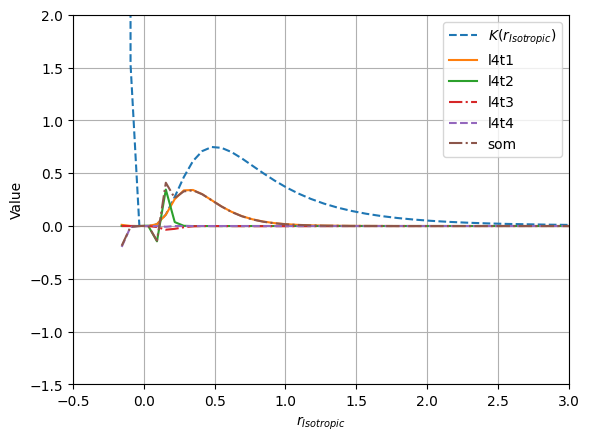

In [14]:
idx= -1 #time index
#idx = 0 #initial time 

l4t1 = -line4_1[idx]
l4t2 = -line4_2[idx]
l4t3 = -line4_3[idx]
l4t4 = -line4_4[idx]

som = (l4t1+l4t2+l4t3+l4t4)

plt.plot(r, Kretschmann(iso_to_sz(r)), label='$K(r_{Isotropic})$', linestyle='--')

plt.plot(r, l4t1, label = 'l4t1', linestyle="-")
plt.plot(r, l4t2, label = 'l4t2', linestyle="-")
plt.plot(r, l4t3, label = 'l4t3', linestyle="-.")
plt.plot(r, l4t4, label = 'l4t4', linestyle="--")

plt.plot(r, som, label = 'som', linestyle="-.")



plt.legend(loc='best')
plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend(loc='best')
'''plt.xlim(-0.1,2)
plt.ylim(-10,1200)'''


plt.xlim(-0.5,3)
plt.ylim(-1.5,2)

'''plt.xlim(-5,80)
plt.ylim(-5,90)'''
plt.grid()
# plt.savefig('KvsGB_t_not_0')

# $M_{ij}M^{ij}$

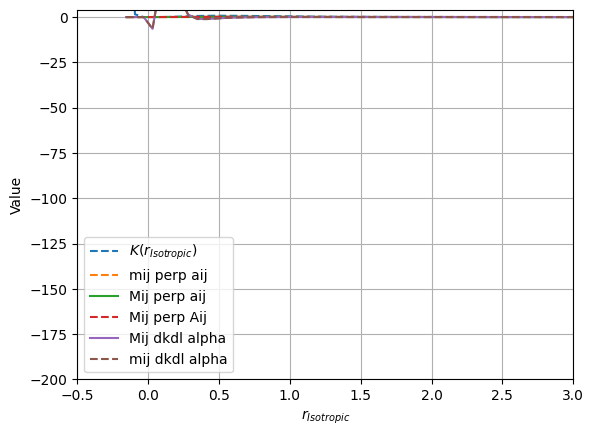

In [15]:
idx= -1 #time index
#idx = 0 #initial time 

Mij1 = MTFsquared[idx]
Mij2 = MTFsquared2[idx]
Mij3 = MTFsquared3[idx]
Mij4 = MTFsquared4[idx]
Mij5 = MTFsquared5[idx]
Mij6 = MTFsquared6[idx]
Mij7 = MTFsquared7[idx]
Mij8 = MTFsquared8[idx]

plt.plot(r, Kretschmann(iso_to_sz(r)), label='$K(r_{Isotropic})$', linestyle='--')

#plt.plot(r, Mij1, label = 'Mij Mij', linestyle="-")
#plt.plot(r, Mij2, label = 'Mij Aij', linestyle="-")
#plt.plot(r, Mij3, label = 'mij aij', linestyle="-")
plt.plot(r, Mij4, label = 'mij perp aij', linestyle="--")
plt.plot(r, Mij5, label = 'Mij perp aij', linestyle="-")
plt.plot(r, Mij6, label = 'Mij perp Aij', linestyle="--")
plt.plot(r, Mij7, label = 'Mij dkdl alpha', linestyle="-")
plt.plot(r, Mij8, label = 'mij dkdl alpha', linestyle="--")

plt.legend(loc='best')
plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend(loc='best')
'''plt.xlim(-0.1,2)
plt.ylim(-10,1200)'''

plt.xlim(-0.5,3)
plt.ylim(-200,4)

'''plt.xlim(-5,80)
plt.ylim(-5,90)'''
plt.grid()
# plt.savefig('KvsGB_t_not_0')

# 

## 

# Hamilton value Vs Trace $M_{ij}$

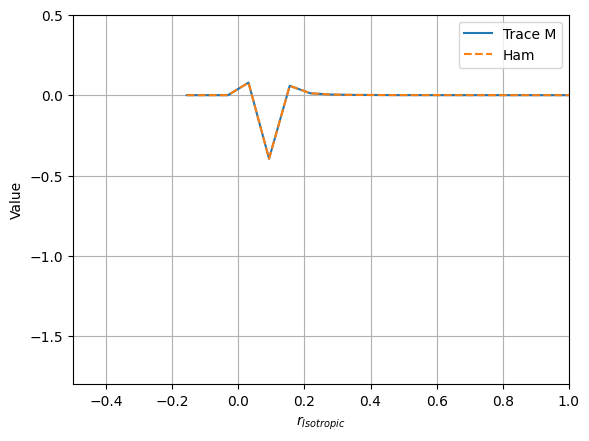

In [16]:
idx= 0
ham = Hamilton[idx]
TM = Trace_M_list[idx]

plt.plot(r, TM, label="Trace M")
plt.plot(r, ham, label="Ham",linestyle='--')

plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.xlim(-0.5, 1)
plt.ylim(-1.8, 0.5)
plt.savefig("Hamiltonian Constraint")

In [17]:
print(len(Hamilton))
print(len(Trace_M_list))

248
248


# Momentum value vs $N^i$ (I have used upper index now)

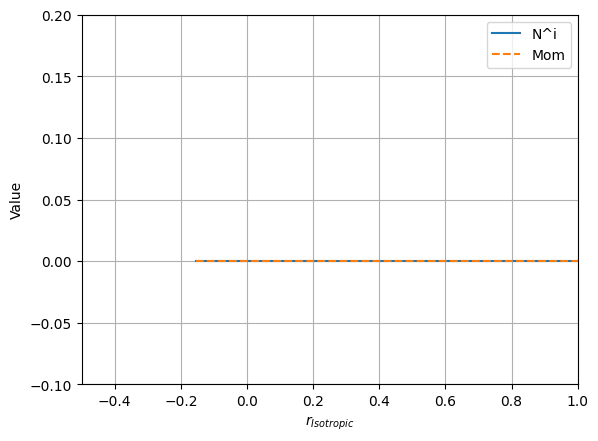

In [19]:
idx= 0
Mom = Momentum[idx]
N = Ennn[idx]

N_lister = []
for i in range(len(N)):
    N_lister.append(N[i][0])

Mom_lister = []
for i in range(len(Mom)):
    Mom_lister.append(Mom[i][0])

plt.plot(r, N_lister, label="N^i")
plt.plot(r, Mom_lister, label="Mom",linestyle='--')

plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.xlim(-0.5, 1)
plt.ylim(-0.1, 0.2)
plt.savefig('Momentum Constraint')

#

# 

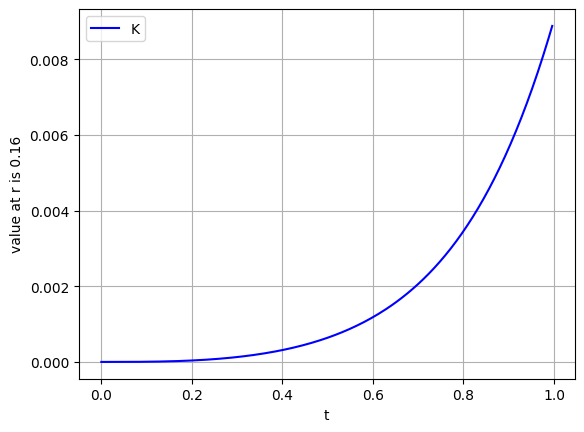

In [19]:
# Plot a single point versus time
idx_u = 11

var1 = 4

idx = NUM_GHOSTS + 2 # Choose an inner point
r_i = np.round(r[idx],2)
var1_of_t = solution[:, var1 * num_points + idx]
plt.plot(t, var1_of_t, 'b-', label=my_state_vector.VARIABLE_NAMES[var1])

"""
var2_of_t = solution[:, var2 * num_points + idx]
plt.plot(t, var2_of_t, 'g-', label=my_state_vector.VARIABLE_NAMES[var2])


var3_of_t = solution[:, var3 * num_points + idx]
plt.plot(t, var3_of_t, 'g-', label=my_state_vector.VARIABLE_NAMES[var3])'''
"""
plt.legend(loc='best')
plt.xlabel('t')
plt.ylabel('value at r is '+str(r_i))
plt.legend(loc='best')
plt.grid()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(0.0, 3.0)

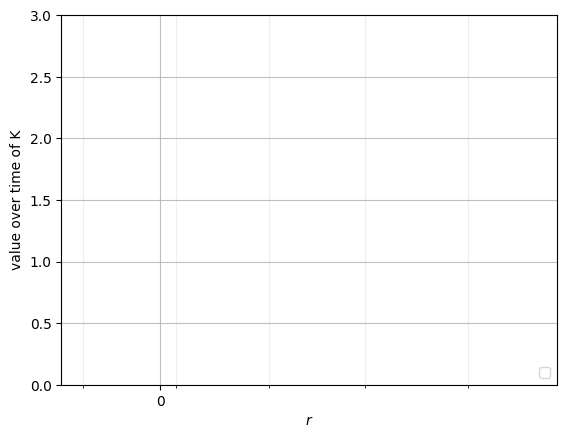

In [20]:
# i is the index of time 
# t_i is the corresponding timie value to that index

# if (i < 1000) and (i % 10 == 0) and (t_i > 9.0):
    # i< 100: times before the 100the time point (only the index of the time)
    # (i % 10 == 0) : every 10th point, avoids to many lines.
    # (t_i > 9.0) : the actual value of the time must be greater than 9 


iii = 10
var = 4
for i, t_i in enumerate(t) :
    if (i < 2000) and (i % 10 == 0) and (t_i > 5.0):
        labelt = "t="+str(round(t_i,2))
        f_t = solution[i, var * num_points: (var + 1) * num_points]
        plt.plot(r, f_t, label=labelt)

plt.legend(loc=4)
plt.xlabel('r')
plt.ylabel('value over time of ' + my_state_vector.VARIABLE_NAMES[var])

ax = plt.gcf().gca()
set_grid_on_ax(ax, r)
plt.xlim(-0.2,0.8)
plt.ylim(0,3)

